In [90]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

In [91]:
server = r"LAPTOP-ID6IL8J4\SQLEXPRESS"
database = "DataWarehouse"

connection_string = (
    "mssql+pyodbc://@"
    + server
    + "/"
    + database
    + "?driver=ODBC+Driver+17+for+SQL+Server"
    + "&trusted_connection=yes"
)

engine = create_engine(connection_string)

In [92]:
with engine.connect() as connection:
    print("Connected successfully!")

Connected successfully!


In [93]:
query = """
SELECT
    s.order_number,
    s.order_date,
    s.sales_amount,
    s.quantity,
    s.price,

    c.customer_key,
    c.customer_id,
    c.first_name,
    c.last_name,
    c.country,
    c.gender,
    c.marital_status,
    c.birthdate,

    p.product_key,
    p.product_name,
    p.category,
    p.subcategory,
    p.cost,
    p.product_line

FROM gold.fact_sales AS s

JOIN gold.dim_customers AS c
    ON s.customer_key = c.customer_key

JOIN gold.dim_products AS p
    ON s.product_key = p.product_key
"""

df = pd.read_sql(query, engine)

# Data Overview

In [94]:
df.head()

,order_number,order_date,sales_amount,quantity,price,customer_key,customer_id,first_name,last_name,country,gender,marital_status,birthdate,product_key,product_name,category,subcategory,cost,product_line
0,SO43697,2010-12-29,3578.0,1,3578.0,10769,21768,Cole,Watson,Canada,Male,Single,1952-02-19,20,Road-150 Red- 62,Bikes,Road Bikes,2171,Road
1,SO43698,2010-12-29,3400.0,1,3400.0,17390,28389,Rachael,Martinez,France,Female,Single,1970-06-17,9,Mountain-100 Silver- 44,Bikes,Mountain Bikes,1912,Mountain
2,SO43699,2010-12-29,3400.0,1,3400.0,14864,25863,Sydney,Wright,United States,Female,Single,1952-06-01,9,Mountain-100 Silver- 44,Bikes,Mountain Bikes,1912,Mountain
3,SO43700,2010-12-29,699.0,1,699.0,3502,14501,Ruben,Prasad,United States,Male,Married,1943-11-10,41,Road-650 Black- 62,Bikes,Road Bikes,487,Road
4,SO43701,2010-12-29,3400.0,1,3400.0,4,11003,Christy,Zhu,Australia,Female,Single,1973-08-14,9,Mountain-100 Silver- 44,Bikes,Mountain Bikes,1912,Mountain


In [95]:
df.shape

(60380, 19)

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60380 entries, 0 to 60379
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_number    60380 non-null  str    
 1   order_date      60380 non-null  object 
 2   sales_amount    60365 non-null  float64
 3   quantity        60380 non-null  int64  
 4   price           60365 non-null  float64
 5   customer_key    60380 non-null  int64  
 6   customer_id     60380 non-null  int64  
 7   first_name      60380 non-null  str    
 8   last_name       60380 non-null  str    
 9   country         60380 non-null  str    
 10  gender          60380 non-null  str    
 11  marital_status  60380 non-null  str    
 12  birthdate       60301 non-null  object 
 13  product_key     60380 non-null  int64  
 14  product_name    60380 non-null  str    
 15  category        60380 non-null  str    
 16  subcategory     60380 non-null  str    
 17  cost            60380 non-null  int64  
 1

In [97]:
df.isnull().sum()

order_number       0
order_date         0
sales_amount      15
quantity           0
price             15
customer_key       0
customer_id        0
first_name         0
last_name          0
country            0
gender             0
marital_status     0
birthdate         79
product_key        0
product_name       0
category           0
subcategory        0
cost               0
product_line       0
dtype: int64

# Handling Missing value 

In [98]:
df["sales_amount"]=df["sales_amount"].fillna(df["sales_amount"].mean())
df["price"]=df["price"].fillna(df["price"].mean())

df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")
df["birthdate"]=df["birthdate"].fillna(df["birthdate"].median())



# Numerical Analysis


In [99]:
df.describe()

,sales_amount,quantity,price,customer_key,customer_id,birthdate,product_key,cost
count,60380.000000,60380.000000,60380.000000,60380.000000,60380.000000,60380,60380.000000,60380.000000
mean,486.223027,1.000414,486.211944,7842.286204,18841.286204,1969-05-28 13:03:50,212.273601,292.606724
min,2.000000,1.000000,-54.000000,1.000000,11000.000000,1916-02-10 00:00:00,3.000000,1.000000
25%,8.000000,1.000000,8.000000,3004.000000,14003.000000,1961-12-17 00:00:00,138.000000,3.000000
50%,30.000000,1.000000,30.000000,7144.000000,18143.000000,1971-08-15 00:00:00,246.000000,11.000000
75%,540.000000,1.000000,540.000000,12430.250000,23429.250000,1978-07-10 00:00:00,285.000000,295.000000
max,3578.000000,10.000000,3578.000000,18484.000000,29483.000000,1986-06-25 00:00:00,295.000000,2171.000000
std,928.470817,0.044018,928.475775,5432.336380,5432.336380,NaN,80.076177,563.287197


In [100]:
mean_of_sales=df["sales_amount"].mean()
median_of_sales=df["sales_amount"].median()

print(mean_of_sales)
print(median_of_sales)

486.2230265882548
30.0


In [101]:
df["sales_amount"].max()

3578.0

In [102]:
df["sales_amount"].min()


2.0

# Categorical Analysis

In [103]:
df["country"].value_counts()

country
United States     20467
Australia         13343
Canada             7619
United Kingdom     6904
Germany            5625
France             5551
n/a                 871
Name: count, dtype: int64

In [104]:
df["gender"].value_counts()

gender
Male      30352
Female    29995
n/a          33
Name: count, dtype: int64

In [105]:
df["category"].value_counts()

category
Accessories    36077
Bikes          15203
Clothing        9100
Name: count, dtype: int64

In [106]:
df["product_line"].value_counts()

product_line
Other Sales    23353
Mountain       16890
Road           15548
Touring         4589
Name: count, dtype: int64

# Group by analysis 

### 1. Which product categories generate the highest sales?

In [107]:
category_sales = (
    df.groupby("category")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

category
Bikes          2.831166e+07
Accessories    7.058579e+05
Clothing       3.406314e+05
Name: sales_amount, dtype: float64

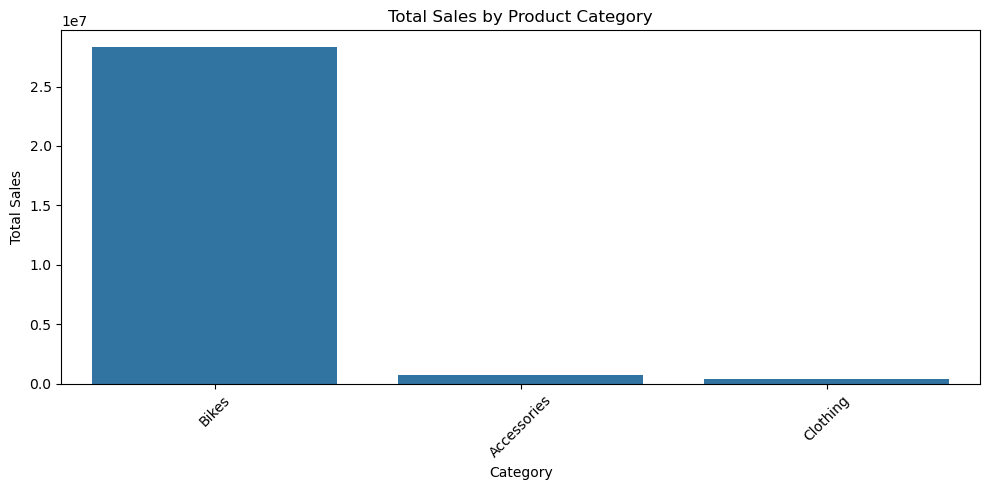

In [108]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [109]:
category_sales.idxmax(), category_sales.max()

('Bikes', 28311657.0)

 ### 2. Which countries contribute the most revenue? 

In [110]:
country_sales = (
    df.groupby("country")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
)

country_sales

country
United States     9.163663e+06
Australia         9.062879e+06
United Kingdom    3.389507e+06
Germany           2.894543e+06
France            2.641699e+06
Canada            1.979035e+06
n/a               2.268200e+05
Name: sales_amount, dtype: float64

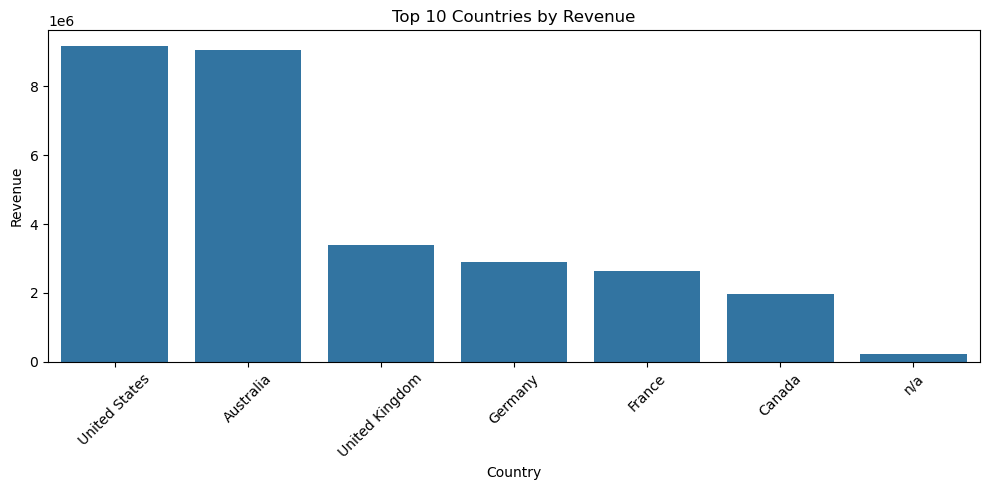

In [111]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=country_sales.head(10).index,
    y=country_sales.head(10).values
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Which products are the top-selling products?

In [112]:
top_products = (
    df.groupby("product_name")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

product_name
Mountain-200 Black- 46     1373454.0
Mountain-200 Black- 42     1363128.0
Mountain-200 Silver- 38    1339394.0
Mountain-200 Silver- 46    1298709.0
Mountain-200 Black- 38     1292559.0
Mountain-200 Silver- 42    1257368.0
Road-150 Red- 48           1205786.0
Road-150 Red- 62           1202208.0
Road-150 Red- 52           1080556.0
Road-150 Red- 56           1055510.0
Name: sales_amount, dtype: float64

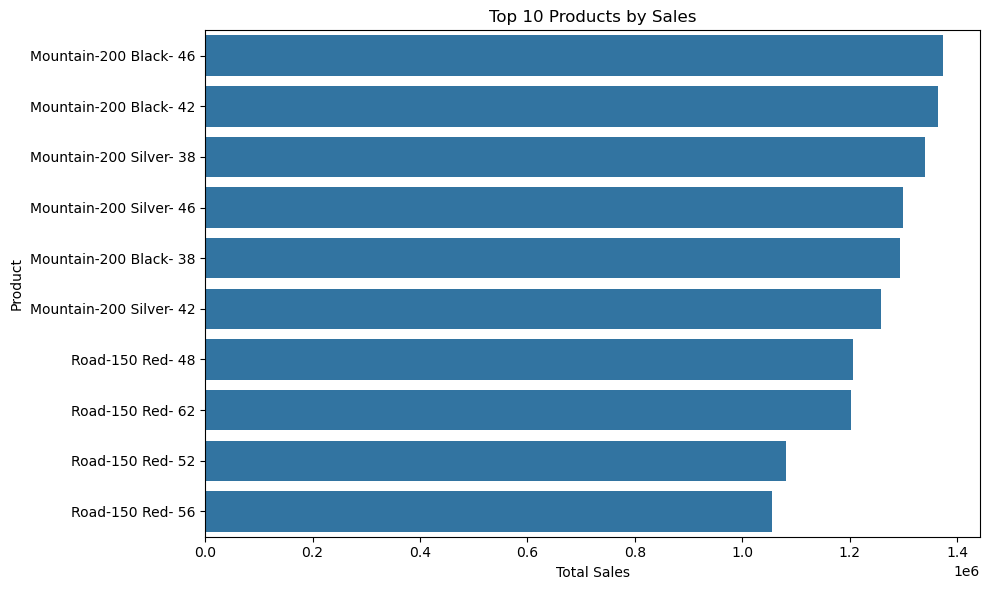

In [113]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### 4. What is the distribution of sales amounts?

In [114]:
df["sales_amount"].describe()

count    60380.000000
mean       486.223027
std        928.470817
min          2.000000
25%          8.000000
50%         30.000000
75%        540.000000
max       3578.000000
Name: sales_amount, dtype: float64

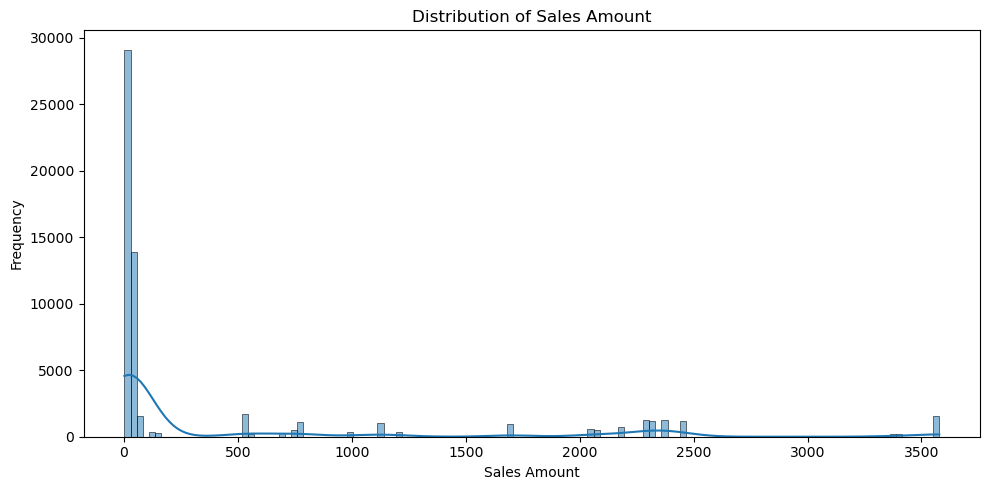

In [115]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="sales_amount",
    kde=True
)

plt.title("Distribution of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

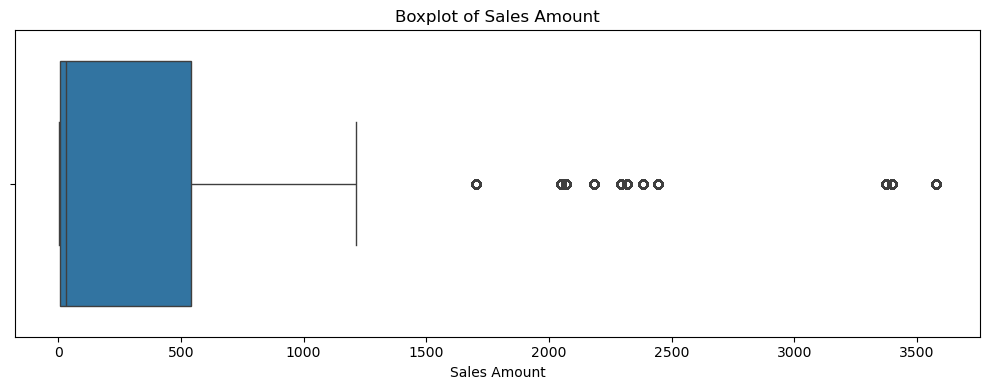

In [116]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["sales_amount"]
)

plt.title("Boxplot of Sales Amount")
plt.xlabel("Sales Amount")

plt.tight_layout()
plt.show()

### 5. Which customer segments contribute the most sales?

In [117]:
gender_sales = (
    df.groupby("gender")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
)

gender_sales

gender
Female    1.480758e+07
Male      1.452088e+07
n/a       2.968900e+04
Name: sales_amount, dtype: float64

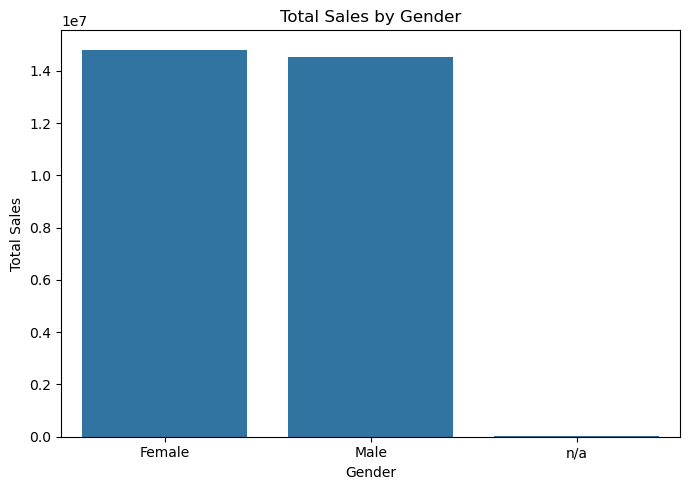

In [118]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values
)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [119]:
#Sales by marital status 
marital_sales = (
    df.groupby("marital_status")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
)

marital_sales

marital_status
Married    1.518594e+07
Single     1.417221e+07
Name: sales_amount, dtype: float64

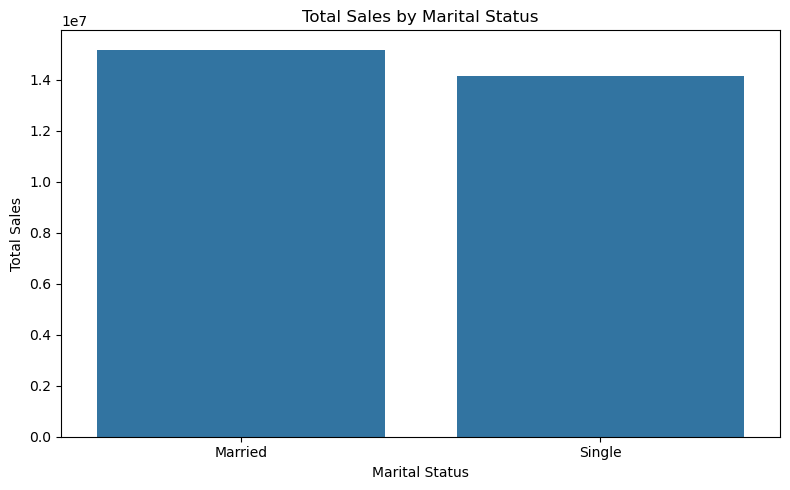

In [120]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=marital_sales.index,
    y=marital_sales.values
)

plt.title("Total Sales by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### 6. Is there a relationship between quantity and sales amount?

In [121]:
df[["quantity", "sales_amount"]].corr()

,quantity,sales_amount
quantity,1.000000,-0.001288
sales_amount,-0.001288,1.000000


In [122]:
correlation = df["quantity"].corr(df["sales_amount"])

print("Correlation:", correlation)

Correlation: -0.0012878638347484375


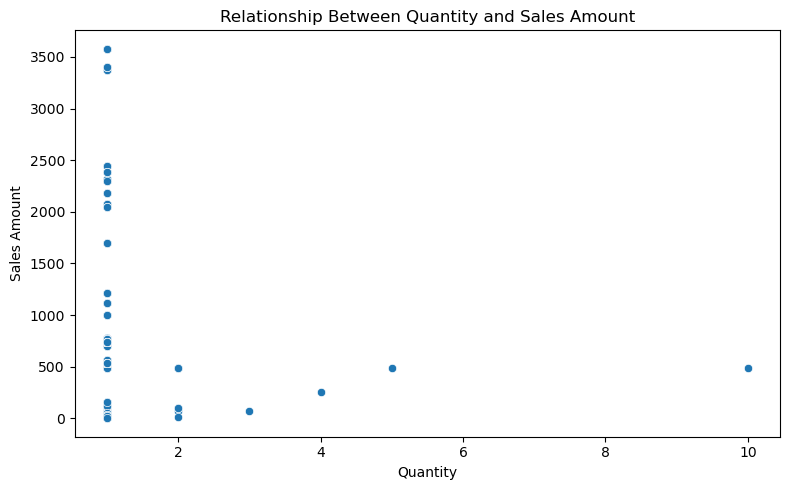

In [123]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="quantity",
    y="sales_amount"
)

plt.title("Relationship Between Quantity and Sales Amount")
plt.xlabel("Quantity")
plt.ylabel("Sales Amount")

plt.tight_layout()
plt.show()

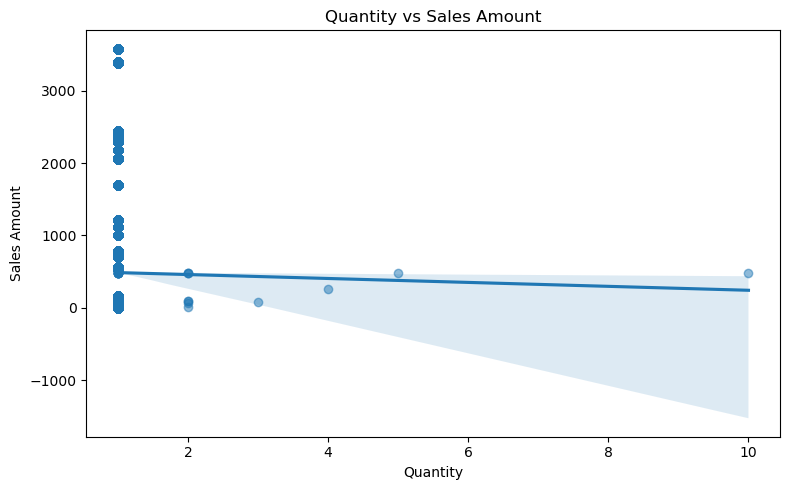

In [124]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="quantity",
    y="sales_amount",
    scatter_kws={"alpha": 0.5}
)

plt.title("Quantity vs Sales Amount")
plt.xlabel("Quantity")
plt.ylabel("Sales Amount")

plt.tight_layout()
plt.show()

### Interpretation

Close to +1 → strong positive relationship
Close to  0 → weak/no linear relationship
Close to -1 → strong negative relationship

### 7. Which product categories have the highest average selling price?

In [125]:
category_price = (
    df.groupby("category")["price"]
      .mean()
      .sort_values(ascending=False)
)

category_price

category
Bikes          1862.241466
Clothing         37.370047
Accessories      19.562401
Name: price, dtype: float64

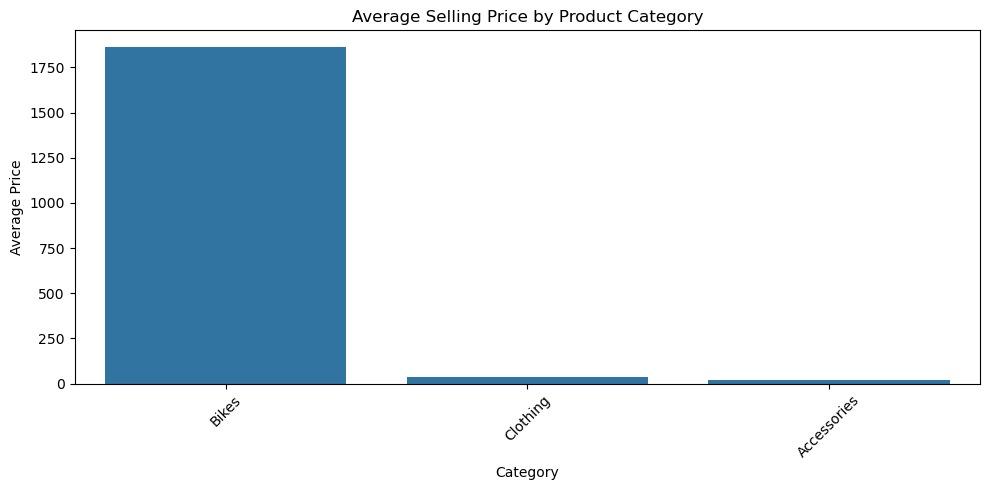

In [126]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=category_price.index,
    y=category_price.values
)

plt.title("Average Selling Price by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [127]:
category_price.idxmax(), category_price.max()

('Bikes', 1862.24146550023)

### 8. How do sales change over time?

In [128]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [129]:
monthly_sales = (
    df.set_index("order_date")
      .resample("ME")["sales_amount"]
      .sum()
)

monthly_sales

order_date
2010-12-31     43419.0
2011-01-31    469795.0
2011-02-28    466307.0
2011-03-31    485165.0
2011-04-30    502042.0
                ...   
5488-09-30         0.0
5488-10-31         0.0
5488-11-30         0.0
5488-12-31         0.0
5489-01-31         5.0
Freq: ME, Name: sales_amount, Length: 41738, dtype: float64

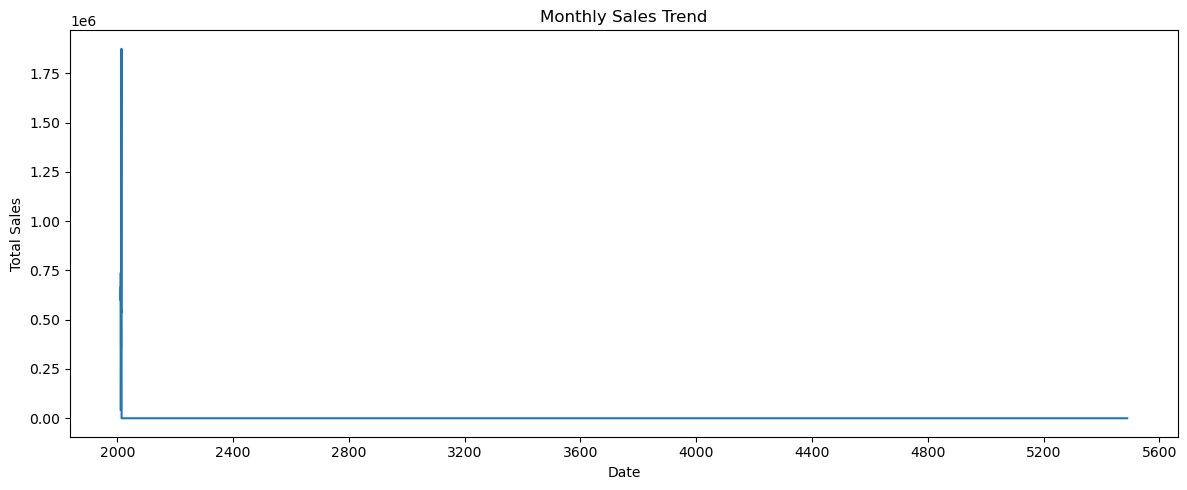

In [130]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

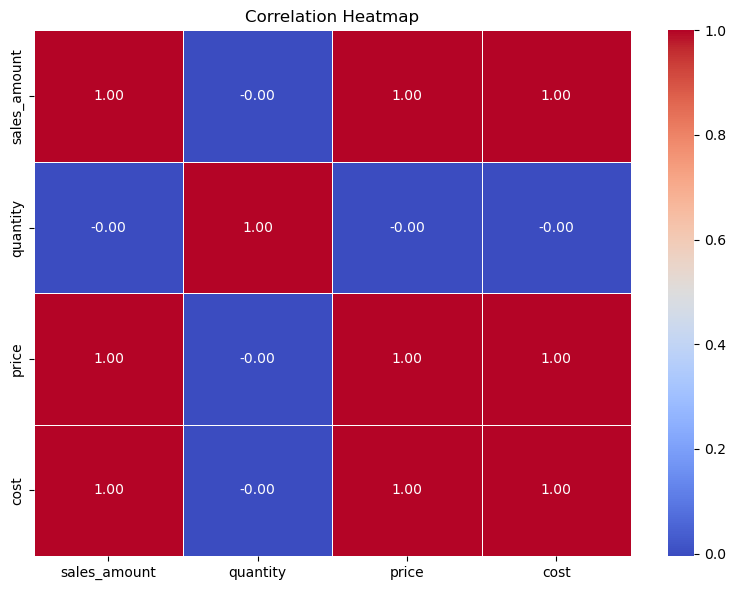

In [131]:
numeric_cols = [
    "sales_amount",
    "quantity",
    "price",
    "cost"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

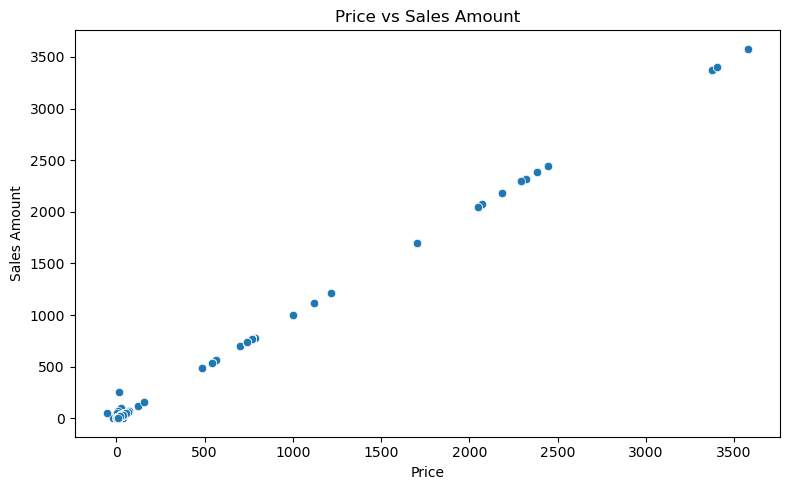

In [132]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="price",
    y="sales_amount"
)

plt.title("Price vs Sales Amount")
plt.xlabel("Price")
plt.ylabel("Sales Amount")

plt.tight_layout()
plt.show()

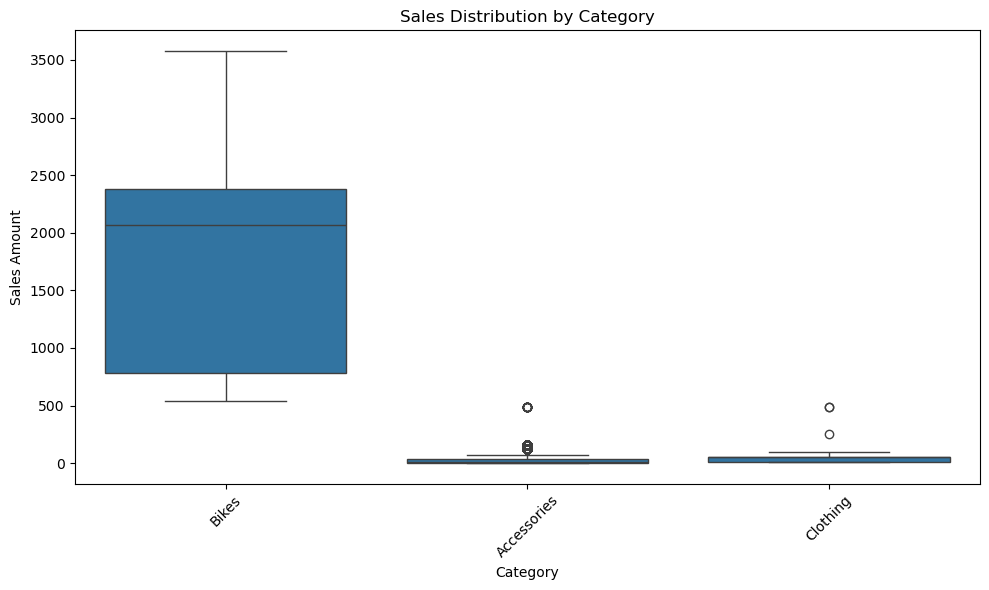

In [133]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="category",
    y="sales_amount"
)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

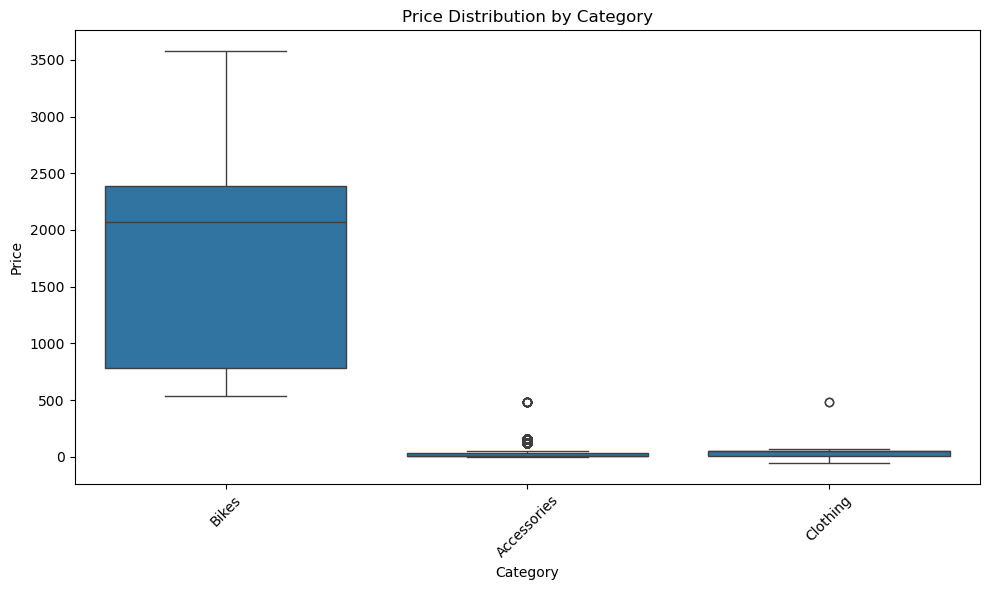

In [134]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="category",
    y="price"
)

plt.title("Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 9. Conclusion

This analysis explored sales, product, customer, and pricing patterns using data from the Gold layer of the SQL Data Warehouse. Pandas was used for data analysis, while Matplotlib and Seaborn were used for visualization. The analysis helped identify important sales trends, top-performing products and categories, customer patterns, pricing differences, and relationships between numerical variables.